# Entrega 3 · Evaluación ampliada

Este cuaderno compara el baseline (RandomForest con 132 features) frente al pipeline PCA + SVM (60 componentes) usando validación cruzada y mediciones de latencia. Los artefactos se guardan en `Entrega 3/artifacts/`.


In [44]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


In [45]:
PROJECT_ROOT = Path('.').resolve()
ENTREGA2_PATH = PROJECT_ROOT / 'Entrega 2'
ENTREGA3_PATH = PROJECT_ROOT / 'Entrega 3'
ARTIFACTS_PATH = ENTREGA3_PATH / 'artifacts'
ARTIFACTS_PATH.mkdir(parents=True, exist_ok=True)

LANDMARKS_CSV = ENTREGA2_PATH / 'landmarks_data.csv'
if not LANDMARKS_CSV.exists():
    raise FileNotFoundError(f"No encuentro {LANDMARKS_CSV}. Genera/exporta el CSV desde Entrega 2.")

landmarks_df = pd.read_csv(LANDMARKS_CSV)
print(landmarks_df.shape)
landmarks_df.head()


(13035, 133)


,0_x,0_y,0_z,0_v,1_x,1_y,1_z,1_v,2_x,2_y,...,30_v,31_x,31_y,31_z,31_v,32_x,32_y,32_z,32_v,class
0,0.419056,0.181214,0.242158,0.999652,0.420217,0.167612,0.160949,0.999597,0.417675,0.167477,...,0.872379,0.277300,0.776001,0.039766,0.925620,0.385196,0.730761,0.505285,0.794547,atras
1,0.422976,0.181181,0.246730,0.999609,0.421860,0.167688,0.164632,0.999549,0.418480,0.167546,...,0.875385,0.277288,0.765799,0.047610,0.925866,0.385064,0.729794,0.505651,0.796320,atras
2,0.433355,0.180700,0.251780,0.999608,0.429510,0.167638,0.168614,0.999542,0.424477,0.167509,...,0.880771,0.274615,0.746793,0.252565,0.922207,0.388084,0.727026,0.529869,0.796374,atras
3,0.440365,0.179886,0.273644,0.999619,0.434974,0.167462,0.192190,0.999548,0.429029,0.167316,...,0.887158,0.268603,0.740661,0.260996,0.919406,0.392293,0.727191,0.526102,0.797088,atras
4,0.442957,0.179591,0.274256,0.999634,0.436698,0.167356,0.192897,0.999560,0.430557,0.167191,...,0.892730,0.261259,0.723440,0.322839,0.911464,0.401974,0.725774,0.529382,0.789858,atras


In [46]:
label_encoder = LabelEncoder()

X = landmarks_df.drop(columns=['class'])
y = landmarks_df['class']
y_encoded = label_encoder.fit_transform(y)
feature_names = X.columns.tolist()

print(f"Total muestras: {X.shape[0]}")
print(f"Features: {len(feature_names)}")
print(pd.Series(label_encoder.classes_).reset_index().rename(columns={'index': 'encoded_label', 0: 'class'}))


Total muestras: 13035
Features: 132
   encoded_label     class
0              0  adelante
1              1     atras
2              2     girar
3              3   pararse
4              4  sentarse


In [47]:
def make_rf_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('classifier', RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=1,
            class_weight='balanced',
            n_jobs=-1,
            random_state=42
        ))
    ])


def make_pca_svm_pipeline(n_components=60):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components, random_state=42)),
        ('classifier', SVC(kernel='rbf', C=10, gamma=0.01, class_weight='balanced', probability=False, random_state=42))
    ])


In [48]:
def cross_validate_model(pipeline, X, y, cv_splits=5):
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    fold_metrics = []
    fold_reports = []
    fold_confusions = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average='macro')
        report_dict = classification_report(y_test, y_pred, target_names=label_encoder.classes_, output_dict=True)
        report_df = pd.DataFrame(report_dict).transpose()
        cm = confusion_matrix(y_test, y_pred)

        fold_metrics.append({
            'fold': fold_idx,
            'accuracy': acc,
            'macro_f1': macro_f1
        })
        fold_reports.append(report_df)
        fold_confusions.append(cm)

    metrics_df = pd.DataFrame(fold_metrics)
    avg_report_df = pd.concat(fold_reports).groupby(level=0).mean()
    sum_confusion = np.sum(fold_confusions, axis=0)

    return {
        'metrics_df': metrics_df,
        'avg_metrics': {
            'accuracy_mean': metrics_df['accuracy'].mean(),
            'accuracy_std': metrics_df['accuracy'].std(),
            'macro_f1_mean': metrics_df['macro_f1'].mean(),
            'macro_f1_std': metrics_df['macro_f1'].std()
        },
        'reports_df_list': fold_reports,
        'avg_report_df': avg_report_df,
        'confusion_matrix_sum': sum_confusion
    }


In [49]:
rf_pipeline = make_rf_pipeline()
pca60_pipeline = make_pca_svm_pipeline(n_components=60)

rf_cv = cross_validate_model(rf_pipeline, X, y_encoded, cv_splits=5)
pca60_cv = cross_validate_model(pca60_pipeline, X, y_encoded, cv_splits=5)

rf_cv['metrics_df']


,fold,accuracy,macro_f1
0,1,0.990794,0.992863
1,2,0.991178,0.992671
2,3,0.987725,0.990097
3,4,0.988109,0.989936
4,5,0.989643,0.990823


In [50]:
print('RF CV metrics:', rf_cv['avg_metrics'])
print('PCA+SVM CV metrics:', pca60_cv['avg_metrics'])


RF CV metrics: {'accuracy_mean': np.float64(0.9894898350594554), 'accuracy_std': 0.0015486481962551915, 'macro_f1_mean': np.float64(0.9912780191213384), 'macro_f1_std': 0.001401276584918853}
PCA+SVM CV metrics: {'accuracy_mean': np.float64(0.9881089374760261), 'accuracy_std': 0.001974612608551402, 'macro_f1_mean': np.float64(0.989246187811009), 'macro_f1_std': 0.0021257380377434623}


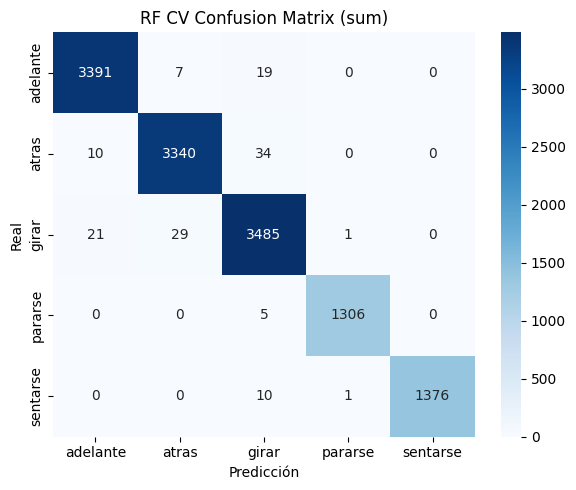

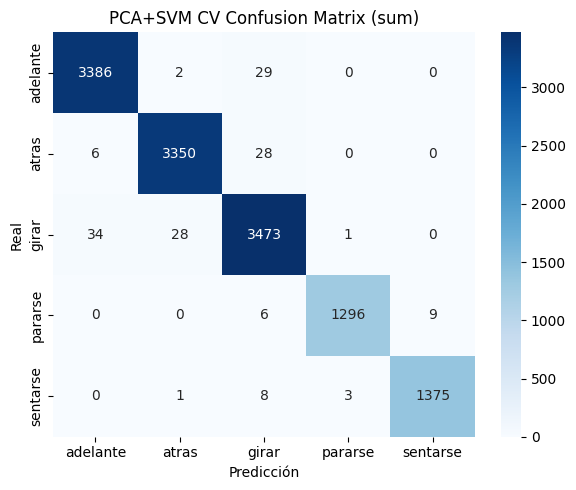

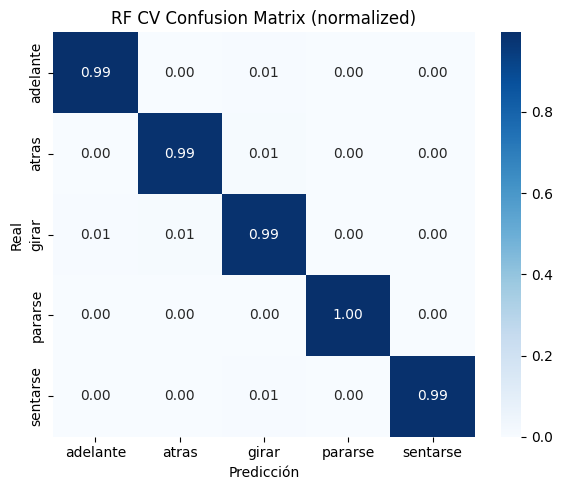

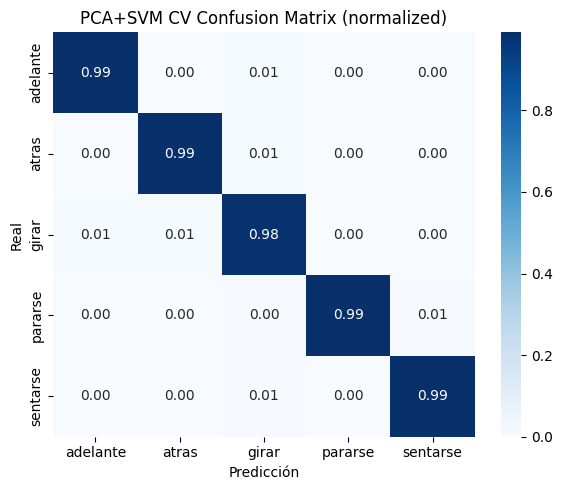

In [51]:
def plot_confusion(cm, classes, title, normalize=True):
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='.2f' if normalize else 'd', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()

plot_confusion(rf_cv['confusion_matrix_sum'], label_encoder.classes_, 'RF CV Confusion Matrix (sum)', normalize=False)
plot_confusion(pca60_cv['confusion_matrix_sum'], label_encoder.classes_, 'PCA+SVM CV Confusion Matrix (sum)', normalize=False)
plot_confusion(rf_cv['confusion_matrix_sum'], label_encoder.classes_, 'RF CV Confusion Matrix (normalized)', normalize=True)
plot_confusion(pca60_cv['confusion_matrix_sum'], label_encoder.classes_, 'PCA+SVM CV Confusion Matrix (normalized)', normalize=True)


In [52]:
def report_to_dataframe(report_df):
    index_labels = list(label_encoder.classes_) + ['accuracy', 'macro avg', 'weighted avg']
    df = report_df.loc[index_labels]
    return df

rf_report_df = report_to_dataframe(rf_cv['avg_report_df'])
pca60_report_df = report_to_dataframe(pca60_cv['avg_report_df'])

rf_report_df, pca60_report_df

(              precision    recall  f1-score     support
 adelante       0.990976  0.992391  0.991664   683.40000
 atras          0.989353  0.986997  0.988169   676.80000
 girar          0.980887  0.985576  0.983214   707.20000
 pararse        0.998476  0.996192  0.997326   262.20000
 sentarse       1.000000  0.992073  0.996016   277.40000
 accuracy       0.989490  0.989490  0.989490     0.98949
 macro avg      0.991938  0.990646  0.991278  2607.00000
 weighted avg   0.989532  0.989490  0.989497  2607.00000,
               precision    recall  f1-score      support
 adelante       0.988367  0.990928  0.989621   683.400000
 atras          0.990834  0.989952  0.990392   676.800000
 girar          0.979997  0.982185  0.981079   707.200000
 pararse        0.996943  0.988567  0.992721   262.200000
 sentarse       0.993525  0.991357  0.992418   277.400000
 accuracy       0.988109  0.988109  0.988109     0.988109
 macro avg      0.989933  0.988598  0.989246  2607.000000
 weighted avg   0.9881

In [53]:
cv_summary = pd.DataFrame([
    {
        'model': 'RandomForest_132f',
        **rf_cv['avg_metrics']
    },
    {
        'model': 'PCA60_SVM',
        **pca60_cv['avg_metrics']
    }
])
cv_summary


,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std
0,RandomForest_132f,0.989490,0.001549,0.991278,0.001401
1,PCA60_SVM,0.988109,0.001975,0.989246,0.002126


In [54]:
cv_results_path = ARTIFACTS_PATH / 'cv_results.csv'
cv_summary.to_csv(cv_results_path, index=False)

rf_report_df = report_to_dataframe(rf_cv['avg_report_df'])
pca60_report_df = report_to_dataframe(pca60_cv['avg_report_df'])

rf_report_path = ARTIFACTS_PATH / 'cv_rf_report.csv'
pca_report_path = ARTIFACTS_PATH / 'cv_pca60_report.csv'

rf_report_df.to_csv(rf_report_path)
pca60_report_df.to_csv(pca_report_path)

print(f"Guardado resumen CV en {cv_results_path}")
print(f"Reportes por clase guardados en {rf_report_path} y {pca_report_path}")


Guardado resumen CV en /content/Entrega 3/artifacts/cv_results.csv
Reportes por clase guardados en /content/Entrega 3/artifacts/cv_rf_report.csv y /content/Entrega 3/artifacts/cv_pca60_report.csv


In [55]:
def benchmark_inference(pipeline, X_sample, n_runs=5):
    timings = []
    for _ in range(n_runs):
        start = time.perf_counter()
        pipeline.predict(X_sample)
        end = time.perf_counter()
        timings.append(end - start)
    avg_time = np.mean(timings)
    return {
        'avg_time': avg_time,
        'std_time': np.std(timings),
        'samples': X_sample.shape[0]
    }

# Pre-entrenar pipelines en todo el dataset antes de medir
rf_pipeline.fit(X, y_encoded)
pca60_pipeline.fit(X, y_encoded)

sample_size = 200
X_sample = X.iloc[:sample_size]
rf_latency = benchmark_inference(rf_pipeline, X_sample)
pca_latency = benchmark_inference(pca60_pipeline, X_sample)

print('RF latency:', rf_latency)
print('PCA+SVM latency:', pca_latency)


RF latency: {'avg_time': np.float64(0.14123073999999178), 'std_time': np.float64(0.007639697434559948), 'samples': 200}
PCA+SVM latency: {'avg_time': np.float64(0.0782448726000439), 'std_time': np.float64(0.006731197964990835), 'samples': 200}


In [56]:
latency_report = {
    'rf_baseline': rf_latency,
    'pca60_svm': pca_latency,
    'note': 'Tiempos aproximados con sample_size=200, predict sobre pipelines ya ajustados.'
}

latency_path = ARTIFACTS_PATH / 'latency_report.json'
with open(latency_path, 'w') as fp:
    json.dump(latency_report, fp, indent=2)

print(f"Latencias guardadas en {latency_path}")


Latencias guardadas en /content/Entrega 3/artifacts/latency_report.json
